# 1D Single-Temperature ML Model: $q \to U_{\mathrm{eff}}$

A separate feedforward neural network is trained at each temperature independently, mapping position $q$ to the quantum effective potential $U_{\mathrm{eff}}(q)$ at that fixed temperature. This is the simplest ML experiment. It isolates the position dependence of $U_{\mathrm{eff}}(q)$, and serves as the central basic ML architecture to be tested before the multi-temperature and physics-informed models are built.

The reference data $U_{\mathrm{eff}}^{\mathrm{num}}$ is generated by the numerical solver developed in Notebook 1 (`MSciNumericalSolverNotebook`), with the convention $U_{\mathrm{eff}}(0, \beta) = 0$.

## Model

Each model $\mathrm{NN}_\theta : q \mapsto U_{\mathrm{eff}}(q)$ is a feedforward network with two hidden layers of 32 neurons and $\tanh$ activations. Weights are initialised with the Xavier scheme and optimised using AdamW ($\eta = 10^{-3}$, weight decay $10^{-3}$).

The loss function is the unweighted mean squared error over the training set:

$$\mathcal{L}(\theta) = \frac{1}{N_{\mathrm{train}}} \sum_{i=1}^{N_{\mathrm{train}}} \left[ \mathrm{NN}_\theta(q_i) - U_{\mathrm{eff}}^{\mathrm{num}}(q_i) \right]^2$$

Model selection uses validation-based early stopping: the checkpoint with the lowest validation loss across all epochs is restored after training. This prevents overfitting and removes the need to tune the number of epochs manually.

To characterise data efficiency, models are trained on nested subsets of the training positions at each temperature. The relative RMSE $\varepsilon_{\mathrm{rel}}^{\mathrm{test}} = \mathrm{RMSE}_{\mathrm{test}} / \sigma(U_{\mathrm{eff}})$ is the primary error metric, normalising against the spread of the target on the test set.


In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import copy
from matplotlib.ticker import ScalarFormatter

## Numerical Solver

In [2]:
class QuantumSystem1D:
    """
    Lean quantum solver: diagonalises the 1D Hamiltonian and computes
    the effective potential U_eff(q, β) from the thermal density matrix.

    Uses atomic units: ℏ = m = ω = k_B = 1.
    """

    def __init__(self, V, qmin, qmax, n_points, m=1.0, ℏ=1.0):
        self.V = V
        self.qmin = qmin
        self.qmax = qmax
        self.n_points = n_points
        self.m = m
        self.ℏ = ℏ
        self.q_grid = np.linspace(qmin, qmax, n_points)
        self.q_delta = self.q_grid[1] - self.q_grid[0]
        self._solve_eigenproblem()

    def _solve_eigenproblem(self):
        """Construct and diagonalise the Hamiltonian (finite-difference discretisation)."""
        H = np.zeros((self.n_points, self.n_points))
        kinetic_diag = self.ℏ**2 / (self.m * self.q_delta**2)
        kinetic_off  = -self.ℏ**2 / (2.0 * self.m * self.q_delta**2)

        for i in range(self.n_points):
            for j in range(self.n_points):
                if i == j:
                    H[i, j] = kinetic_diag + self.V(self.q_grid[i])[0]
                elif abs(i - j) == 1:
                    H[i, j] = kinetic_off

        eigenvalues, eigenvectors = np.linalg.eigh(H)
        eigenvectors = eigenvectors.T
        for i in range(len(eigenvectors)):
            norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))
            eigenvectors[i] /= norm

        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors
        print(f"Solved: {self.n_points} states, E₀ = {eigenvalues[0]:.6f}, E₁ = {eigenvalues[1]:.6f}")

    def thermal_density_diagonal(self, β):
        """⟨q|e^{-βH}|q⟩ = Σₙ |ψₙ(q)|² e^{-β Eₙ}"""
        ρ = np.zeros_like(self.q_grid)
        for E, ψ in zip(self.eigenvalues, self.eigenvectors):
            ρ += ψ**2 * np.exp(-β * E)
        return ρ

    def effective_potential_quantum(self, β):
        """U_eff(q, β) = -(1/β) ln ρ(q,q;β), pinned so U_eff(0) = 0."""
        ρ = self.thermal_density_diagonal(β)
        U = -(1.0 / β) * np.log(np.maximum(ρ, 1e-300))
        q0_idx = np.argmin(np.abs(self.q_grid))
        return U - U[q0_idx]

## Harmonic Potential and Data Generation

In [3]:
def V_harmonic(q):
    k = 1.0
    return 0.5 * k * q**2, k * q, k * q**0

# solver generates data on the full grid [-10, 10]
system = QuantumSystem1D(V_harmonic, qmin=-10, qmax=10, n_points=200, m=1.0, ℏ=1.0)
q_grid = system.q_grid
n_pos  = len(q_grid)

n_temperatures = 10
temperatures = np.logspace(np.log10(0.1), np.log10(10.0), n_temperatures)

U_eff_data = np.zeros((n_temperatures, n_pos))
for t_idx, T in enumerate(temperatures):
    β = 1.0 / T
    U_eff_data[t_idx] = system.effective_potential_quantum(β)

# restrict to |q| < 9 for all ML work — avoids boundary artefacts at ±10
mask_q    = np.abs(q_grid) < 9
q_grid_ml = q_grid[mask_q]
n_pos_ml  = len(q_grid_ml)
U_eff_ml  = U_eff_data[:, mask_q]

print(f"Solver:    {n_temperatures} temperatures × {n_pos} positions")
print(f"ML region: {n_pos_ml} positions in |q| < 9")
print(f"T range:   [{temperatures[0]:.4f}, {temperatures[-1]:.4f}]")

Solved: 200 states, E₀ = 0.499684, E₁ = 1.498420
Solver:    10 temperatures × 200 positions
ML region: 180 positions in |q| < 9
T range:   [0.1000, 10.0000]


/tmp/ipykernel_19724/1444519054.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))


## Model and Training

Each 1D model is a feedforward network $q \to U_{\mathrm{eff}}$ with two hidden layers of 32 neurons, $\tanh$ activations, Xavier initialisation, and the AdamW optimiser. Training uses unweighted MSE loss with validation-based model selection (best validation epoch restored).

In [4]:
def build_model_1d(hidden_dims=[32, 32]):
    """Feedforward network: q -> U_eff. Xavier init, tanh activations."""
    layers = []
    d_in = 1
    for d_h in hidden_dims:
        layers.append(nn.Linear(d_in, d_h))
        layers.append(nn.Tanh())
        d_in = d_h
    layers.append(nn.Linear(d_in, 1))
    model = nn.Sequential(*layers)
    for layer in model:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
    return model


def train_1d(model, X_train, y_train, X_val, y_val, epochs, lr):
    """
    Train with unweighted MSE and AdamW optimiser.
    Returns model (restored to best val epoch), train history, val history.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    best_val_loss = float('inf')
    best_state    = None
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = nn.functional.mse_loss(pred, y_train)
        loss.backward()
        optimizer.step()
        train_hist.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = nn.functional.mse_loss(model(X_val), y_val).item()
            val_hist.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, train_hist, val_hist


def compute_rmse(model, X, y_np):
    """Unweighted RMSE on a dataset."""
    model.eval()
    with torch.no_grad():
        pred = model(X).numpy()
    return np.sqrt(np.mean((pred - y_np)**2))

## Data Splits and Training Setup

At each temperature, the same position indices are held out for validation and testing. The remaining positions form nested training subsets (controlled by `training_fractions`) to characterise data efficiency.

In [5]:
hidden_dims = [32, 32]
epochs      = 3000
lr          = 0.001
seed        = 1

training_fractions = [0.05, 0.10, 0.20, 0.25, 0.40, 0.50, 0.75, 0.80, 1.00]
n_fracs            = len(training_fractions)

n_test = 10
n_val  = 10

rng = np.random.default_rng(seed=seed)
idx_shuf = rng.permutation(n_pos_ml)
test_positions = set(idx_shuf[:n_test])
val_positions  = set(idx_shuf[n_test:n_test + n_val])

is_test  = np.isin(np.arange(n_pos_ml), list(test_positions))
is_val   = np.isin(np.arange(n_pos_ml), list(val_positions))
is_train = ~is_test & ~is_val

n_train_total = is_train.sum()

print(f"Per temperature: {n_train_total} train, {n_val} val, {n_test} test positions (|q| < 9)")
print(f"Training fractions: {training_fractions}")


Per temperature: 160 train, 10 val, 10 test positions (|q| < 9)
Training fractions: [0.05, 0.1, 0.2, 0.25, 0.4, 0.5, 0.75, 0.8, 1.0]


## Training

A model is trained independently at each temperature for each training fraction. The full-data model ($f = 1.0$) at each temperature is retained for the prediction plots. The loss history is saved for one representative temperature to illustrate the training dynamics.

In [6]:
# storage
rmse_all    = np.zeros((n_temperatures, n_fracs))
rel_all     = np.zeros((n_temperatures, n_fracs))
ntrain_all  = np.zeros((n_temperatures, n_fracs), dtype=int)
best_models = [None] * n_temperatures  # full-data model per T

# representative temperature for loss curve (middle of log-space)
repr_T_idx = n_temperatures // 2
repr_train_hist = None
repr_val_hist   = None

for t_idx, T in enumerate(temperatures):
    β = 1.0 / T
    U = U_eff_ml[t_idx]
    σ_T = np.std(U[is_test])

    q_train = q_grid_ml[is_train].reshape(-1, 1)
    U_train = U[is_train].reshape(-1, 1)
    q_val   = q_grid_ml[is_val].reshape(-1, 1)
    U_val   = U[is_val].reshape(-1, 1)
    q_test  = q_grid_ml[is_test].reshape(-1, 1)
    U_test  = U[is_test].reshape(-1, 1)

    # shuffle training positions (same seed per T for reproducibility)
    rng_t = np.random.default_rng(seed=seed + t_idx)
    shuf  = rng_t.permutation(len(q_train))
    q_train_s = q_train[shuf]
    U_train_s = U_train[shuf]

    Xv  = torch.tensor(q_val, dtype=torch.float32)
    yv  = torch.tensor(U_val, dtype=torch.float32)
    Xte = torch.tensor(q_test, dtype=torch.float32)

    for f_idx, frac in enumerate(training_fractions):
        n_tr = max(1, int(len(q_train_s) * frac))
        Xt = torch.tensor(q_train_s[:n_tr], dtype=torch.float32)
        yt = torch.tensor(U_train_s[:n_tr], dtype=torch.float32)

        model = build_model_1d(hidden_dims)
        model, t_hist, v_hist = train_1d(model, Xt, yt, Xv, yv, epochs, lr)

        rmse_all[t_idx, f_idx]  = compute_rmse(model, Xte, U_test)
        rel_all[t_idx, f_idx]   = rmse_all[t_idx, f_idx] / max(σ_T, 1e-10)
        ntrain_all[t_idx, f_idx] = n_tr

        if frac == 1.0:
            best_models[t_idx] = model
            if t_idx == repr_T_idx:
                repr_train_hist = t_hist
                repr_val_hist   = v_hist

    print(f"T = {T:.4f}  done  |  ε_rel^test(full) = {rel_all[t_idx, -1]:.4f}")

print("\nAll temperatures trained.")

T = 0.1000  done  |  ε_rel^test(full) = 0.0190
T = 0.1668  done  |  ε_rel^test(full) = 0.0142
T = 0.2783  done  |  ε_rel^test(full) = 0.0151
T = 0.4642  done  |  ε_rel^test(full) = 0.0146
T = 0.7743  done  |  ε_rel^test(full) = 0.0242
T = 1.2915  done  |  ε_rel^test(full) = 0.0210
T = 2.1544  done  |  ε_rel^test(full) = 0.0154
T = 3.5938  done  |  ε_rel^test(full) = 0.0227
T = 5.9948  done  |  ε_rel^test(full) = 0.0224
T = 10.0000  done  |  ε_rel^test(full) = 0.0200

All temperatures trained.


## Results

### Predictions at Each Temperature

The full-data model at each temperature is evaluated across $q \in [-9, 9]$. Solid black: numerical $U_{\mathrm{eff}}^{\mathrm{num}}$; dashed blue: NN prediction.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

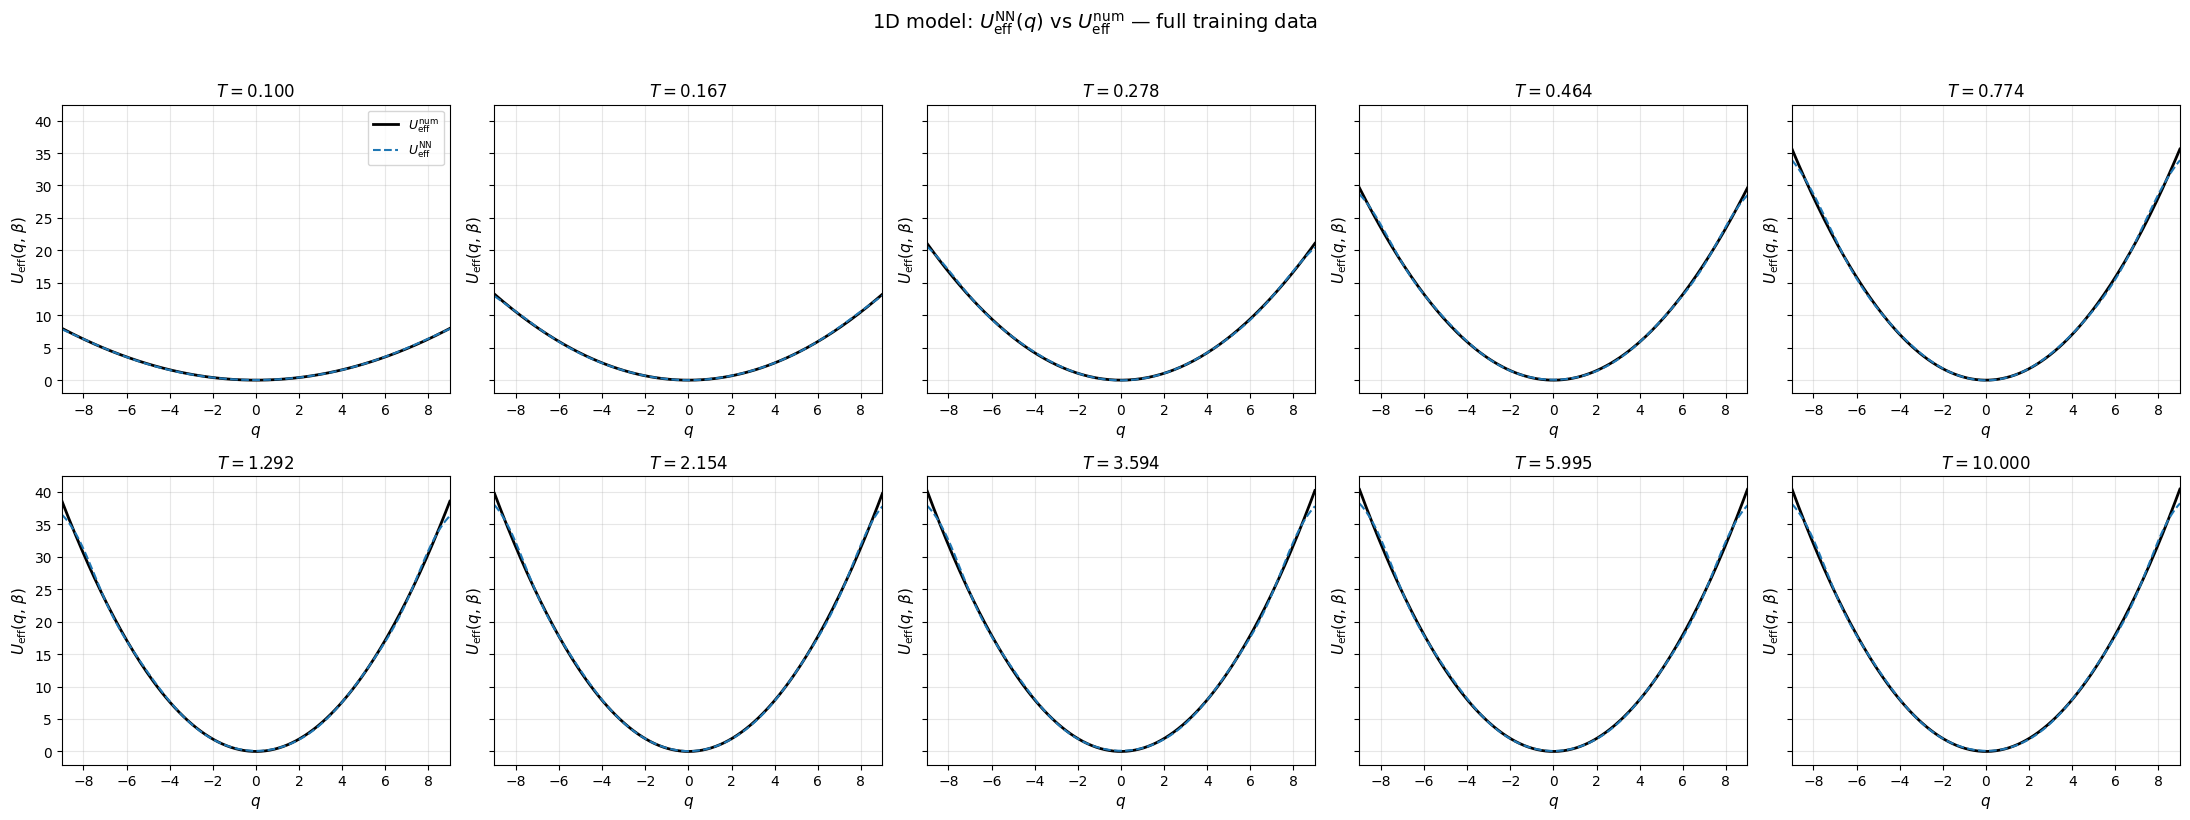

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
q_dense = np.linspace(-9, 9, 500).reshape(-1, 1)
q_dense_t = torch.tensor(q_dense, dtype=torch.float32)

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    model = best_models[idx]
    model.eval()
    with torch.no_grad():
        y_pred = model(q_dense_t).numpy().flatten()

    ax.plot(q_grid_ml, U_eff_ml[idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense.flatten(), y_pred, '--', lw=1.5, color='tab:blue',
            label=r'$U_{\mathrm{eff}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_\mathrm{eff}(q,\,\beta)$', fontsize=11)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.set_xlim(-9, 9)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=9)

fig.suptitle(r'1D model: $U_{\mathrm{eff}}^{\mathrm{NN}}(q)$ vs $U_{\mathrm{eff}}^{\mathrm{num}}$ — full training data',
             fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig('1D-ML-predictions.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('1D-ML-predictions.pdf')

plt.show()


### Per-Temperature Relative Error

The relative RMSE $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}(T) = \mathrm{RMSE}_{\mathrm{test}}(T) / \sigma(U_{\mathrm{eff}}^T)$ on the test set, evaluated using the full-data model at each temperature.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

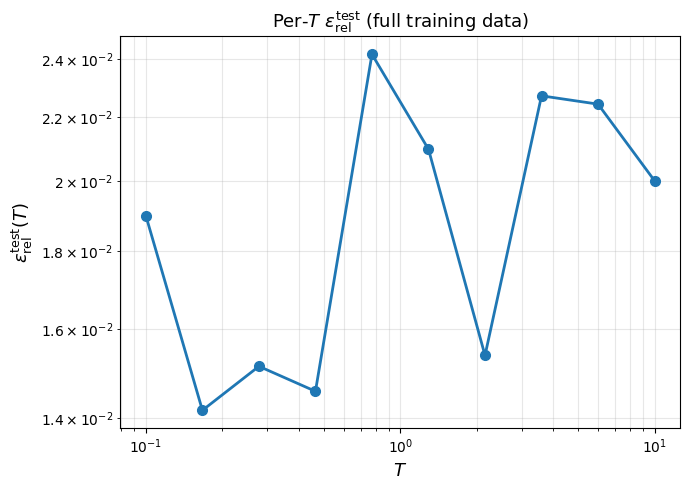

         T       ε_rel
    0.1000    0.018978
    0.1668    0.014171
    0.2783    0.015139
    0.4642    0.014582
    0.7743    0.024188
    1.2915    0.020973
    2.1544    0.015388
    3.5938    0.022726
    5.9948    0.022443
   10.0000    0.020004


In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(temperatures, rel_all[:, -1], 'o-', color='tab:blue', lw=2, ms=7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$T$', fontsize=13)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}(T)$', fontsize=13)
ax.set_title(r'Per-$T$ $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$ (full training data)', fontsize=13)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('1D-Errors-v-T.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('1D-Errors-v-T.pdf')

plt.show()

print(f"{'T':>10}  {'ε_rel':>10}")
for T, e in zip(temperatures, rel_all[:, -1]):
    print(f"{T:10.4f}  {e:10.6f}")


### Learning Curves

$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$ as a function of training set size $N_{\mathrm{train}}$, shown independently at each temperature. The plateau location indicates the minimum data required for convergence.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

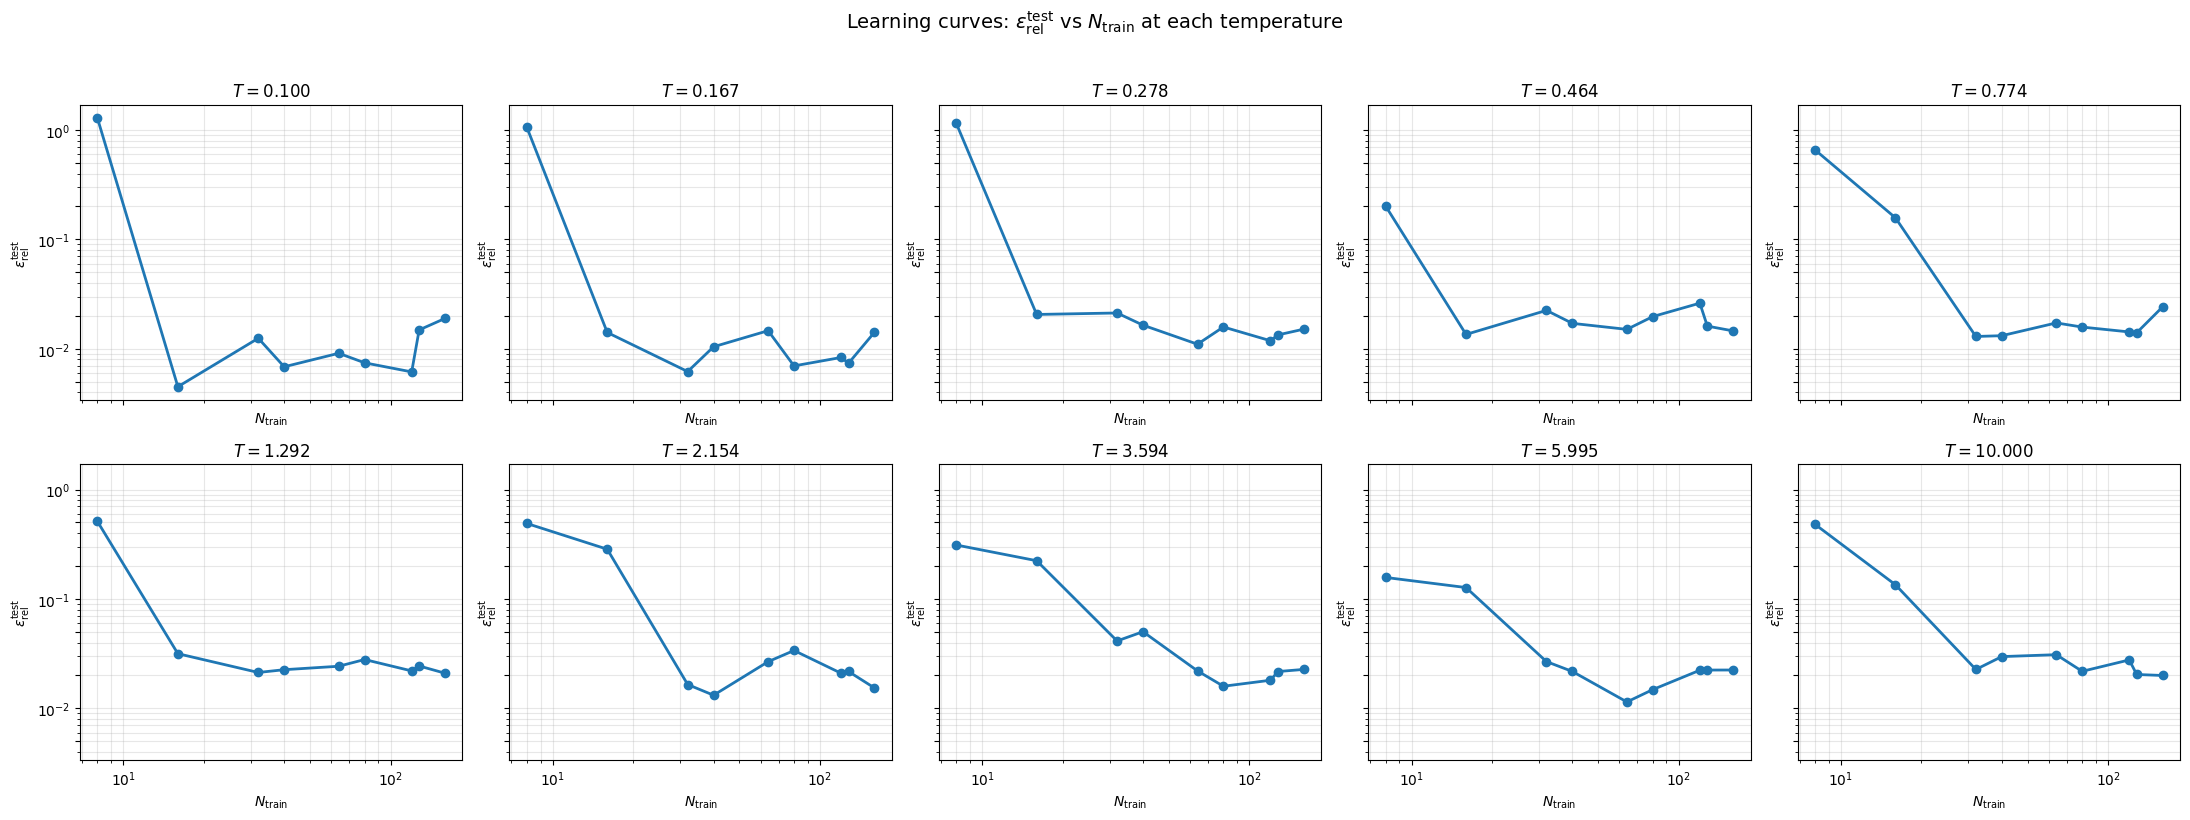

In [23]:
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True, sharey=True)
for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    ax.plot(ntrain_all[idx], rel_all[idx], 'o-', color='tab:blue', lw=2, ms=6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\mathrm{train}}$', fontsize=10)
    ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$', fontsize=10)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.grid(True, alpha=0.3, which='both')
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 5], numticks=20))
    ax.yaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase=False))
fig.suptitle(r'Learning curves: $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$ vs $N_{\mathrm{train}}$ at each temperature',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('1D-Learning-Curves.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('1D-Learning-Curves.pdf')
plt.show()


### Training Dynamics

Train and validation loss (MSE) as a function of epoch for the full-data model at a representative temperature $T_{\mathrm{repr}}$. The vertical dashed line marks the epoch restored by early stopping (lowest validation loss).

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

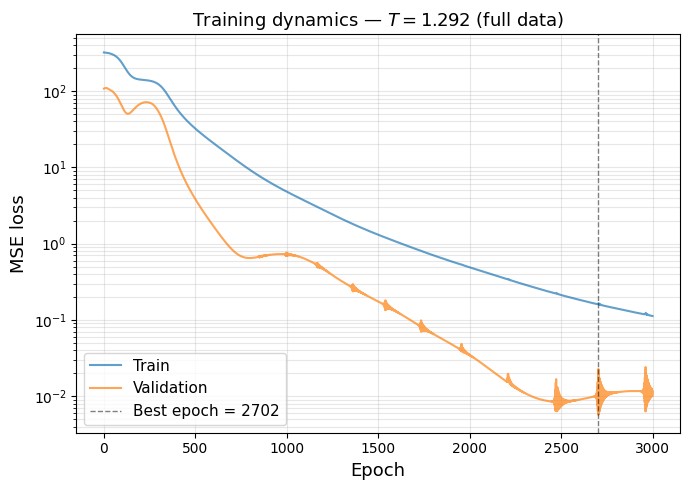

Representative T = 1.2915
Best epoch: 2702
Final train loss: 1.124006e-01
Best val loss:    5.729394e-03


In [24]:
repr_T = temperatures[repr_T_idx]
best_epoch = np.argmin(repr_val_hist)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(repr_train_hist, lw=1.5, color='tab:blue', alpha=0.7, label='Train')
ax.plot(repr_val_hist,   lw=1.5, color='tab:orange', alpha=0.7, label='Validation')
ax.axvline(best_epoch, ls='--', color='k', lw=1, alpha=0.5, label=f'Best epoch = {best_epoch}')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE loss', fontsize=13)
ax.set_title(f'Training dynamics — $T = {repr_T:.3f}$ (full data)', fontsize=13)
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('1D-Validation-Curve.pdf', bbox_inches='tight', dpi=300)
from google.colab import files
files.download('1D-Validation-Curve.pdf')
plt.show()

print(f"Representative T = {repr_T:.4f}")
print(f"Best epoch: {best_epoch}")
print(f"Final train loss: {repr_train_hist[-1]:.6e}")
print(f"Best val loss:    {repr_val_hist[best_epoch]:.6e}")